In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
data_dir = "/content/drive/My Drive/LungMRI"     #change dataset path

classes = os.listdir(data_dir)


In [ ]:
from glob import glob

images = []
labels = []

IMG_SIZE = 224

for cls in os.listdir(data_dir):
    class_path = os.path.join(data_dir, cls)

    # 🔥 Load all formats
    img_paths = glob(class_path + "/*.*")

    print(f"Loading {cls}: {len(img_paths)} images")

    for img_path in img_paths:
        img = cv2.imread(img_path)

        if img is None:
            continue  # skip unreadable files

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img)
        labels.append(cls)

images = np.array(images)
labels = np.array(labels)

print("Total images loaded:", len(images))
print("Unique labels:", np.unique(labels))

In [ ]:
#Preprocessing
import cv2
import numpy as np

def preprocess_image(img):

    # Resize
    img = cv2.resize(img,(224,224))

    # CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    cl = clahe.apply(l)

    merged = cv2.merge((cl,a,b))

    img = cv2.cvtColor(
        merged,
        cv2.COLOR_LAB2BGR
    )

    # Normalization
    img = img.astype(np.float32)/255.0

    return img


images_pp = np.array([
    preprocess_image(img)
    for img in images
])

print(images_pp.shape)

#Label Encoding
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

y = le.fit_transform(labels)

num_classes = len(np.unique(y))

y = to_categorical(y,num_classes)

print(num_classes)

(1264, 224, 224, 3)
2


In [ ]:
#Create Federated Clients
NUM_CLIENTS = 5

client_data = []

split_size = len(images_pp)//NUM_CLIENTS

for i in range(NUM_CLIENTS):

    start = i*split_size

    end = (i+1)*split_size

    x_client = images_pp[start:end]
    y_client = y[start:end]

    client_data.append(
        (x_client,y_client)
    )

print("Clients:",len(client_data))

#Sparse Attention Layer
import tensorflow as tf
from tensorflow.keras.layers import *

class SparseAttention(Layer):

    def __init__(self,embed_dim,num_heads):

        super().__init__()

        self.att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

    def call(self,x):

        attn = self.att(x,x)

        mask = tf.cast(
            attn > tf.reduce_mean(attn),
            tf.float32
        )

        return attn*mask
#Transformer Branch
def transformer_branch(inp):

    x = Conv2D(
        64,
        3,
        padding='same',
        activation='relu'
    )(inp)

    x = Reshape((-1,64))(x)

    x = SparseAttention(
        embed_dim=64,
        num_heads=4
    )(x)

    x = GlobalAveragePooling1D()(x)
    print(x.shape)
    return x
#Inception Recurrent Branch
def inception_recurrent_branch(inp):

    b1 = Conv2D(
        32,
        1,
        activation='relu',
        padding='same'
    )(inp)

    b2 = Conv2D(
        32,
        3,
        activation='relu',
        padding='same'
    )(inp)

    b3 = Conv2D(
        32,
        5,
        activation='relu',
        padding='same'
    )(inp)

    x = Concatenate()([b1,b2,b3])

    x = Reshape((-1,96))(x)

    x = Bidirectional(
        GRU(
            64,
            return_sequences=False
        )
    )(x)

    return x

Clients: 5


In [ ]:
#Proposed FL Disease Classification Model
from tensorflow.keras.models import Model

def build_model(num_classes):

    inp = Input(shape=(224,224,3))

    t_branch = transformer_branch(inp)

    i_branch = inception_recurrent_branch(inp)

    x = Concatenate()(
        [t_branch,i_branch]
    )

    x = Dense(
        512,
        activation='relu'
    )(x)

    x = Dropout(0.3)(x)

    x = Dense(
        256,
        activation='relu'
    )(x)

    out = Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = Model(inp,out)

    return model
#Dynamic Edge Thresholding Client Selection
def select_clients(client_data):

    scores = []

    for i,(x,y) in enumerate(client_data):

        score = len(x)

        scores.append(score)

    threshold = np.mean(scores)

    selected = []

    for i,s in enumerate(scores):

        if s >= threshold:

            selected.append(i)

    return selected


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

X_train, X_test, Y_train, Y_test = train_test_split(
    images_pp,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

X_train, Y_train = shuffle(
    X_train,
    Y_train,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


NUM_CLIENTS = 2

client_data = []

split_size = len(X_train) // NUM_CLIENTS

for i in range(NUM_CLIENTS):

    start = i * split_size

    if i == NUM_CLIENTS - 1:
        end = len(X_train)
    else:
        end = (i + 1) * split_size

    client_data.append(
        (
            X_train[start:end],
            Y_train[start:end]
        )
    )

print("Clients:", len(client_data))


class SparseAttention(tf.keras.layers.Layer):

    def __init__(self, embed_dim, num_heads):
        super().__init__()

        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

    def call(self, x):

        attn = self.att(x, x)

        threshold = tf.reduce_mean(attn)

        mask = tf.cast(
            attn > threshold,
            tf.float32
        )

        return attn * mask

def transformer_branch(inp):

    x = Conv2D(
        32,
        3,
        activation='relu',
        padding='same'
    )(inp)

    x = MaxPooling2D((2,2))(x)
    x = MaxPooling2D((2,2))(x)
    x = MaxPooling2D((2,2))(x)

    x = Reshape((-1,32))(x)

    x = SparseAttention(
        embed_dim=32,
        num_heads=2
    )(x)

    x = GlobalAveragePooling1D()(x)

    return x

def inception_recurrent_branch(inp):

    b1 = Conv2D(
        16,
        1,
        activation='relu',
        padding='same'
    )(inp)

    b2 = Conv2D(
        16,
        3,
        activation='relu',
        padding='same'
    )(inp)

    b3 = Conv2D(
        16,
        5,
        activation='relu',
        padding='same'
    )(inp)

    x = Concatenate()([b1,b2,b3])

    x = MaxPooling2D((4,4))(x)
    x = MaxPooling2D((4,4))(x)

    x = Reshape((-1,48))(x)

    x = Bidirectional(
        GRU(
            32,
            return_sequences=False
        )
    )(x)

    return x

def build_model(num_classes):

    inp = Input(shape=(224,224,3))

    t_branch = transformer_branch(inp)

    i_branch = inception_recurrent_branch(inp)

    x = Concatenate()(
        [t_branch, i_branch]
    )

    x = Dense(
        128,
        activation='relu'
    )(x)

    x = Dropout(0.3)(x)

    x = Dense(
        64,
        activation='relu'
    )(x)

    out = Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = Model(inp, out)

    return model

global_model = build_model(num_classes)

In [ ]:
import numpy as np

class IAPO:

    def __init__(self,
                 obj_function,
                 pop_size=10,
                 max_iter=20,
                 lb=1e-5,
                 ub=1e-2):

        self.obj_function = obj_function
        self.pop_size = pop_size
        self.max_iter = max_iter
        self.lb = lb
        self.ub = ub

    def optimize(self):

        pop = np.random.uniform(
            self.lb,
            self.ub,
            self.pop_size
        )

        fitness = np.array(
            [self.obj_function(x) for x in pop]
        )

        best_idx = np.argmin(fitness)

        best_pos = pop[best_idx]

        best_fit = fitness[best_idx]

        curve = []

        for itr in range(self.max_iter):

            pop = pop[np.argsort(fitness)]
            fitness = np.sort(fitness)

            for i in range(self.pop_size):

                r = np.random.rand()

                ###################################################
                # Dormancy
                ###################################################

                if r < 0.25:

                    new = np.random.uniform(
                        self.lb,
                        self.ub
                    )

                ###################################################
                # Reproduction
                ###################################################

                elif r < 0.5:

                    new = pop[i] + np.random.randn()*0.1*pop[i]

                ###################################################
                # Autotroph
                ###################################################

                elif r < 0.75:

                    j = np.random.randint(self.pop_size)

                    new = pop[i] + \
                          np.random.rand()*(pop[j]-pop[i])

                ###################################################
                # Heterotroph
                ###################################################

                else:

                    new = best_pos + \
                          np.random.randn()*0.05

                new = np.clip(
                    new,
                    self.lb,
                    self.ub
                )

                fnew = self.obj_function(new)

                if fnew < fitness[i]:

                    pop[i] = new
                    fitness[i] = fnew

            idx = np.argmin(fitness)

            if fitness[idx] < best_fit:

                best_fit = fitness[idx]
                best_pos = pop[idx]

            curve.append(best_fit)

        return best_pos, best_fit, curve

#Objective Function
def objective_function(lr):

    temp_model = build_model(num_classes)

    temp_model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=float(lr)
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']

    )

    hist = temp_model.fit(

        X_train,

        Y_train,

        epochs=1,

        batch_size=8,

        validation_split=0.1,

        verbose=0

    )

    return hist.history["val_loss"][-1]
#Run IAPO
optimizer = IAPO(

    obj_function=objective_function,

    pop_size=8,

    max_iter=10,

    lb=1e-5,

    ub=5e-4

)

best_lr, best_loss, curve = optimizer.optimize()

print("Best Learning Rate :", best_lr)
print("Best Validation Loss :", best_loss)


import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    curve,
    linewidth=3
)

plt.xlabel("Iteration")

plt.ylabel("Validation Loss")

plt.title("Iterative Artificial Protozoa Optimization")

plt.grid(True)

plt.show()

In [ ]:
# Training
ROUNDS = 50

train_acc = []
train_loss = []

test_acc = []
test_loss = []

for rnd in range(ROUNDS):

    print(f"\nRound {rnd+1}")

    local_weights = []

    round_acc = []
    round_loss = []

    for client_id, (x_client, y_client) in enumerate(client_data):

        local_model = build_model(num_classes)

        local_model.set_weights(
            global_model.get_weights()
        )

        local_model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=float(best_lr)
            )
                learning_rate=1e-4
            ),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = local_model.fit(
            x_client,
            y_client,
            epochs=3,
            batch_size=8,
            verbose=1
        )

        round_acc.append(
            history.history['accuracy'][-1]
        )

        round_loss.append(
            history.history['loss'][-1]
        )

        local_weights.append(
            local_model.get_weights()
        )

    avg_weights = []

    for weights in zip(*local_weights):
        avg_weights.append(
            np.mean(weights, axis=0)
        )

    global_model.set_weights(avg_weights)
    global_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=float(best_lr)

    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
    loss, acc = global_model.evaluate(
        X_test,
        Y_test,
        verbose=0
    )

    train_acc.append(np.mean(round_acc))
    train_loss.append(np.mean(round_loss))

    test_acc.append(acc)
    test_loss.append(loss)

    print(
        f"Train Acc={train_acc[-1]:.4f} | "
        f"Test Acc={test_acc[-1]:.4f}"
    )


In [ ]:
@tf.keras.utils.register_keras_serializable()
class SparseAttention(tf.keras.layers.Layer):

    def __init__(self, embed_dim, num_heads, **kwargs):
        super().__init__(**kwargs)

        self.embed_dim = embed_dim
        self.num_heads = num_heads

        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

    def build(self, input_shape):
        self.att.build(
            query_shape=input_shape,
            value_shape=input_shape
        )
        super().build(input_shape)

    def call(self, x):

        attn = self.att(x, x)

        threshold = tf.reduce_mean(attn)

        mask = tf.cast(
            attn > threshold,
            tf.float32
        )

        return attn * mask

    def get_config(self):

        config = super().get_config()

        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads
        })

        return config

In [ ]:
# Save weights only
global_model.save_weights(
    "FL_model.weights.h5"
)

import pandas as pd

history_df = pd.DataFrame({
    "Round": range(1, len(train_acc)+1),
    "Train_Accuracy": train_acc,
    "Test_Accuracy": test_acc,
    "Train_Loss": train_loss,
    "Test_Loss": test_loss
})

history_df

history_df.to_csv(
    "FL_Training_History2_mri.csv",
    index=False
)

print("History Saved")

History Saved


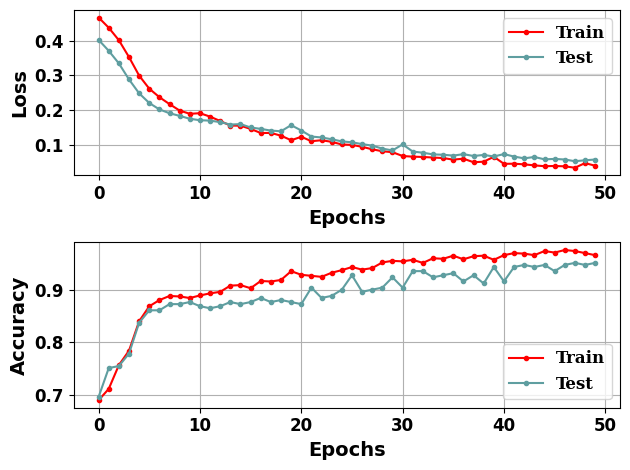

In [ ]:
import matplotlib.pyplot as plt
plt.subplot(211)
plt.plot(np.array(train_loss), label='Train', color='red',marker='o',markersize=3)
plt.plot(np.array(test_loss), label='Test', color='cadetblue',marker='o',markersize=3)
plt.legend(prop={'size': 12, 'weight': 'bold','family':"serif"})  # Bold legend
plt.xlabel('Epochs' , fontsize=14, fontweight="bold")
plt.ylabel('Loss', fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
plt.grid(True)  # Enable grid

# Plot accuracy during training
plt.subplot(212)
plt.plot(np.array(train_acc), label='Train', color='red',marker='o',markersize=3)
plt.plot(np.array(test_acc), label='Test', color='cadetblue',marker='o',markersize=3)
plt.legend(prop={'size': 12, 'weight': 'bold','family':"serif"})  # Bold legend
plt.xlabel('Epochs', fontsize=14, fontweight="bold")
plt.ylabel('Accuracy', fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
# plt.ylim([0.5, 1])  # Set y-axis limit for accuracy (between 0 and 1)
plt.grid(True)  # Enable grid
plt.savefig("accuracy_loss_plot_1.png", dpi=800, bbox_inches="tight")
# Show the plot
plt.tight_layout()
plt.show()

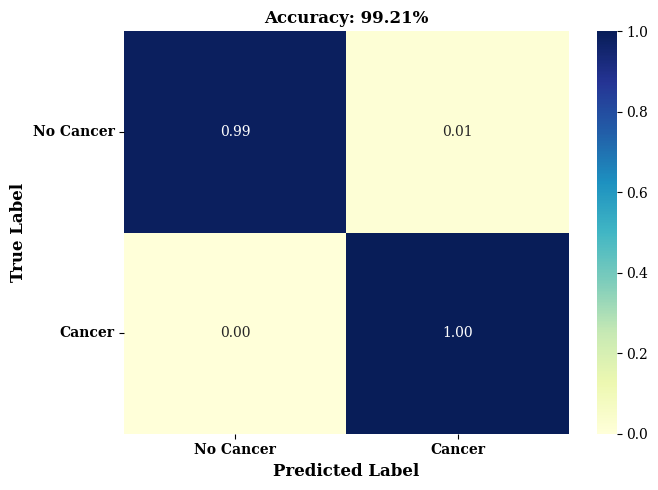

In [ ]:
import numpy as np
import Utils

Y_test = np.argmax(Y_test, axis=1)
Y_train=np.argmax(Y_train, axis=1)

# # Convert probabilities to class labels (integers)
y_true = Y_test
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, mean_squared_error
import seaborn as sns
y_pred=Utils.predict(X_test, Y_test)
accuracy = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
CLASS = ['No Cancer', 'Cancer']
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.rcParams["font.family"] = "serif"

# Improved confusion matrix visualization
plt.figure(figsize=(7,5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=CLASS,
            yticklabels=CLASS)
plt.title(f"Accuracy: {accuracy*100:.2f}%", fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks( fontsize=12, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.savefig("CM.png", dpi=800, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import time, os
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, mean_squared_error
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
categories = CLASS
# =============================
# CLASSIFICATION METRICS
# =============================
def evaluate_classification(y_true, y_pred, categories):
    cm = confusion_matrix(y_true, y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mse = mean_squared_error(y_true, y_pred)

    # Specificity per class
    TN, FP, FN, TP = [], [], [], []
    for i in range(len(categories)):
        TP.append(cm[i, i])
        FP.append(sum(cm[:, i]) - cm[i, i])
        FN.append(sum(cm[i, :]) - cm[i, i])
        TN.append(cm.sum() - (FP[i] + FN[i] + TP[i]))
    specificity_per_class = [TN[i] / (TN[i] + FP[i]) if (TN[i] + FP[i]) > 0 else 0 for i in range(len(categories))]
    specificity = np.mean(specificity_per_class)

    return {
        "Accuracy": float(accuracy),
        "Precision": float(precision),
        "Recall": float(recall),
        "F1-score": float(f1),
        "Specificity": float(specificity),
        "MSE": float(mse)
    }


# =============================
# USAGE
# =============================
if __name__ == "__main__":

    # --- Classification metrics ---
    y_true = Y_test
    print("Classification:", evaluate_classification(y_true, y_pred, categories))


Classification: {'Accuracy': 0.9920948616600791, 'Precision': 0.9901960784313726, 'Recall': 0.9934640522875817, 'F1-score': 0.9917600312662845, 'Specificity': 0.9934640522875817, 'MSE': 0.007905138339920948}


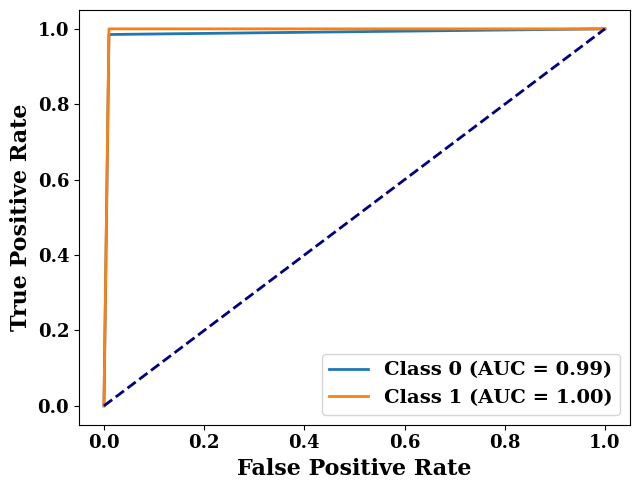

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder

# Convert predicted labels and true labels to numpy arrays
predict = np.array(y_pred)
Y_test = np.array(Y_test)

# Ensure predicted labels are in the same shape as true labels
predict = predict.reshape(-1, 1)

# One-hot encode both Y_test and predicted labels
onehotencoder = OneHotEncoder(sparse_output=False)  # Updated parameter for new versions of sklearn
Y_test_bin = onehotencoder.fit_transform(Y_test.reshape(-1, 1))
ypred_bin = onehotencoder.transform(predict)

# Number of classes
n_classes = Y_test_bin.shape[1]

# Initialize variables to store fpr, tpr, and auc for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], ypred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(7, 5))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontfamily="serif", fontsize=12, fontweight="bold")
plt.ylabel('True Positive Rate', fontfamily="serif", fontsize=12, fontweight="bold")
plt.xticks( fontsize=10, fontfamily="serif", fontweight="bold")
plt.yticks( fontsize=10, fontfamily="serif",  fontweight="bold")
plt.legend(loc='lower right',prop={'family': 'serif', 'size': 12, 'weight': 'bold'})
plt.savefig("ROC.png", dpi=800, bbox_inches="tight")
plt.show()


In [ ]:
class_names = ['No Cancer', 'Cancer']

import matplotlib.pyplot as plt

n = 6  # number of images to display

plt.figure(figsize=(12,6))

for i in range(n):
    plt.subplot(2, 3, i+1)

    plt.imshow(X_test[i])
    plt.axis("off")

    actual = class_names[Y_test[i]]
    pred = class_names[y_pred[i]]

    color = "green" if actual == pred else "red"

    plt.title(f"Actual: {actual}\nPred: {pred}", color=color, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import numpy as np

# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded  = label_encoder.transform(Y_test)

# ============================================================
# ONE HOT ENCODING
# ============================================================

Y_train = to_categorical(Y_train_encoded, num_classes=2)
Y_test  = to_categorical(Y_test_encoded, num_classes=2)

# ============================================================
#  MODEL
# ============================================================


model=global_model

last_conv_layer_name = None

for layer in reversed(model.layers):
    if "conv" in layer.name.lower():
        last_conv_layer_name = layer.name
        break

print(last_conv_layer_name)
# ============================================================
# FIXED GRAD-CAM FUNCTION
# ============================================================

def gradcam(img, model, layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    img = np.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:

        conv_out, preds = grad_model(img)

        pred_index = tf.argmax(preds[0])

        loss = preds[:, pred_index]

    grads = tape.gradient(loss, conv_out)

    weights = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_out = conv_out[0]

    cam = tf.reduce_sum(
        weights * conv_out,
        axis=-1
    )

    cam = tf.maximum(cam, 0)

    cam = cam / (tf.reduce_max(cam) + 1e-8)

    return cam.numpy()

In [ ]:
# model
# model.save("/content/drive/My Drive/LungMRI/model_mri.keras")

# from tensorflow.keras.models import load_model

model = load_model("/content/drive/My Drive/LungMRI/model_mri.keras")

Saving LUNG MRI-NC (8).png to LUNG MRI-NC (8) (2).png


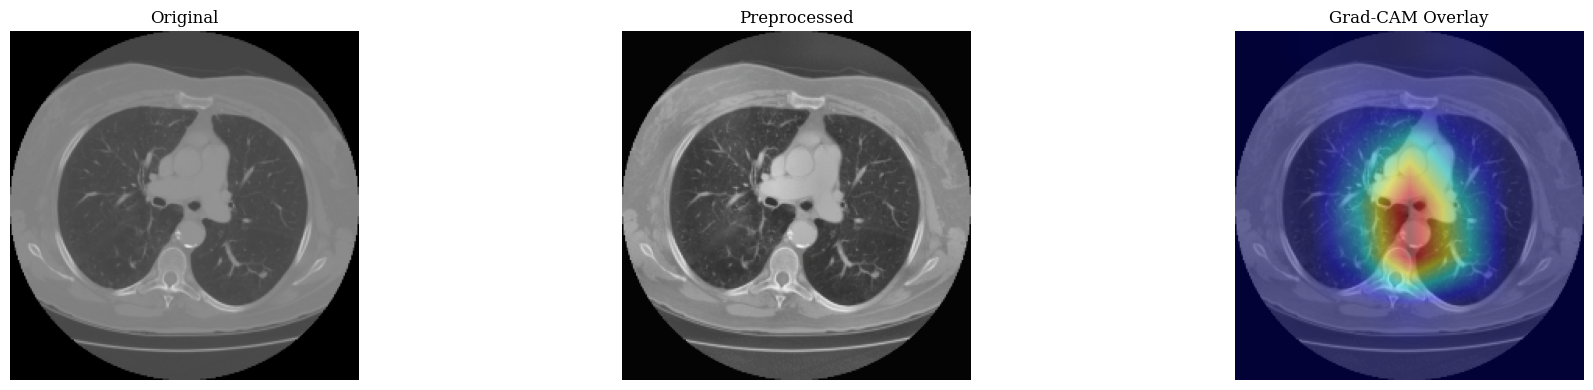

In [ ]:
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
# ============================================================
# UPLOAD IMAGE
# ============================================================

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# ============================================================
# READ IMAGE
# ============================================================

img = cv2.imread(img_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img = cv2.resize(
    img,
    (224,224)
)

# ============================================================
# PREPROCESSED Output
# ============================================================

preprocessed = preprocess_image(img)

# ============================================================
# GRAD-CAM
# ============================================================

heatmap = gradcam(
    preprocessed,
    model,
    last_conv_layer_name
)

# ============================================================
# OVERLAY FUNCTION
# ============================================================

def overlay_gradcam(img, heatmap):

    heatmap = cv2.resize(
        heatmap,
        (224,224)
    )

    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    original = np.uint8(img * 255)

    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    return overlay

# ============================================================
# CREATE GRADCAM OVERLAY
# ============================================================

overlay_img = overlay_gradcam(
    preprocessed,
    heatmap
)

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(20,4))

# ------------------------------------------------------------
# ORIGINAL
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(img)

plt.title("Original")

plt.axis("off")

# ------------------------------------------------------------
# PREPROCESSED
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(preprocessed)

plt.title("Preprocessed")

plt.axis("off")


# ------------------------------------------------------------
# GRAD-CAM OVERLAY
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(overlay_img)

plt.title("Grad-CAM Overlay")

plt.axis("off")

plt.tight_layout()

plt.show()